# 1. Cardiovascular Disease Dataset Preprocessing
# 1.1 Package installs and data loading

In [1]:
# Install important packages

import math
import warnings
import numpy as np
import pandas as pd
import seaborn as sns
from typing import List, Dict
import matplotlib.pyplot as plt
import os
import zipfile
warnings.filterwarnings("ignore", category=DeprecationWarning)

sns.set_style('whitegrid')

dataset_path = './Dataset/cardio_train.csv'

# Load the dataset
print(f"\nLoading dataset from {dataset_path}...")
heart_df = pd.read_csv(dataset_path, delimiter=';')

# Convert age from days to years for interpretability
heart_df['age'] = (heart_df['age'] / 365.25).round().astype(int)

# Rename 'cardio' to 'num' for consistency with rest of notebook
heart_df = heart_df.rename(columns={'cardio': 'num'})

# Remove the 'id' column if it exists
if 'id' in heart_df.columns:
    heart_df = heart_df.drop('id', axis=1)

print(f"\nDataset loaded successfully!")
print(f"Dataset shape: {heart_df.shape}")
print(f"\nColumns: {list(heart_df.columns)}")


Loading dataset from ./Dataset/cardio_train.csv...

Dataset loaded successfully!
Dataset shape: (70000, 12)

Columns: ['age', 'gender', 'height', 'weight', 'ap_hi', 'ap_lo', 'cholesterol', 'gluc', 'smoke', 'alco', 'active', 'num']


# 1.2 Preprocess and Convert to Binary Features

In [2]:
def preprocess_to_binary(df, target_col='num'):
    df_binary = df.copy()

    # Identify feature types
    continuous_cols = ['age', 'height', 'weight', 'ap_hi', 'ap_lo']
    categorical_cols = ['gender', 'cholesterol', 'gluc']
    binary_cols = ['smoke', 'alco', 'active']  # Already binary

    # Data cleaning: Remove outliers and invalid values
    # Remove records with negative or extremely high blood pressure
    df_binary = df_binary[(df_binary['ap_hi'] > 0) & (df_binary['ap_hi'] < 300)]
    df_binary = df_binary[(df_binary['ap_lo'] > 0) & (df_binary['ap_lo'] < 200)]
    
    # Remove records with impossible height/weight
    df_binary = df_binary[(df_binary['height'] > 100) & (df_binary['height'] < 250)]
    df_binary = df_binary[(df_binary['weight'] > 30) & (df_binary['weight'] < 300)]
    
    print(f"After data cleaning: {len(df_binary)} samples (removed {len(df) - len(df_binary)} outliers)")

    # Handle missing values (if any)
    for col in continuous_cols:
        if col in df_binary.columns:
            # Fill missing with median for continuous
            if df_binary[col].isnull().any():
                df_binary[col] = df_binary[col].fillna(df_binary[col].median())

    for col in categorical_cols:
        if col in df_binary.columns:
            # Fill missing with mode for categorical
            if df_binary[col].isnull().any():
                mode_val = df_binary[col].mode()[0] if not df_binary[col].mode().empty else 0
                df_binary[col] = df_binary[col].fillna(mode_val)

    # Convert continuous to binary (1 if > mean, else 0)
    for col in continuous_cols:
        if col in df_binary.columns:
            mean_val = df_binary[col].mean()
            df_binary[col] = (df_binary[col] > mean_val).astype(int)

    # Convert categorical to binary dummy variables
    for col in categorical_cols:
        if col in df_binary.columns:
            # Get dummies (drop_first=False to keep all categories as binary)
            dummies = pd.get_dummies(df_binary[col], prefix=col, drop_first=False).astype(int)
            df_binary = pd.concat([df_binary, dummies], axis=1)
            df_binary.drop(col, axis=1, inplace=True)

    return df_binary

# Apply preprocessing
heart_binary = preprocess_to_binary(heart_df, target_col='num')

print(f"\nBinary dataset shape: {heart_binary.shape}")
print(f"Features: {heart_binary.shape[1] - 1} binary features")
print(f"\nColumns ({len(heart_binary.columns)}): {list(heart_binary.columns)}")

After data cleaning: 68943 samples (removed 1057 outliers)

Binary dataset shape: (68943, 17)
Features: 16 binary features

Columns (17): ['age', 'height', 'weight', 'ap_hi', 'ap_lo', 'smoke', 'alco', 'active', 'num', 'gender_1', 'gender_2', 'cholesterol_1', 'cholesterol_2', 'cholesterol_3', 'gluc_1', 'gluc_2', 'gluc_3']


# 2. Association Rule Classifier with Confidence-Based Weighting

In [3]:
class ACRULE:
    def __init__(self, X, Y):
        # for Rule: X -> Y
        self.antecedent = X                # X
        self.consequent = Y                 # Y
        self.antecedentSUP = 0.0            # SUP(X)
        self.antecedentNConsequentSUP = 0.0 # SUP(XY)
        self.confidence = 0.0               # SUP(XY)/SUP(X)
  
    def toString(self):
        return f"{self.antecedent} ===> {self.consequent} (supportX = {self.antecedentSUP}, supportXY = {self.antecedentNConsequentSUP}, confidence = {self.confidence})"

def notPruneIf_has_all_k_subsets_in_Lk(c: List[str], Lk: Dict[tuple, int]) -> bool:
    """Check Apriori property: all k-subsets are frequent"""
    for idx in range(len(c)):
        subset = tuple(sorted(c[:idx] + c[idx+1:]))
        if subset not in Lk:
            return False
    return True

class ARClassification:
    def __init__(self, transactions, className, classValues, minsup=0.1, minconf=0.8):
        self.T = transactions
        self.minsup = minsup
        self.min_cnt = int(math.ceil(minsup * len(transactions)))
        self.minconf = minconf
        self.className = className
        self.classValues = classValues
        self.allRules = []

    def ConsideringRules(self, allCandidateRules):
        """Count support and confidence, separate Fk and qualified rules"""
        for rule in allCandidateRules:
            rule.antecedentSUP = 0
            rule.antecedentNConsequentSUP = 0
            for t in self.T:
                if all(item in t for item in rule.antecedent):
                    rule.antecedentSUP += 1
                if all(item in t for item in rule.antecedent + rule.consequent):
                    rule.antecedentNConsequentSUP += 1

            rule.confidence = rule.antecedentNConsequentSUP / (rule.antecedentSUP + 1e-20)
           
        Fk = []
        for rule in allCandidateRules:
            if rule.antecedentSUP >= self.min_cnt and rule.confidence >= self.minconf:
                self.allRules.append(rule)
            elif rule.antecedentSUP >= self.min_cnt:
                rule.antecedent.sort()
                Fk.append(rule)

        return Fk

    def FindF1Rules(self):
        allF1Itemsets = set()
        allCandidateRules = []

        # Collect 1-item antecedents (excluding class column)
        for t in self.T:
            for it in t:
                if not any(it == f'{self.className}:{v}' for v in self.classValues):
                    allF1Itemsets.add(it)

        # Generate 1-rule candidates
        for item in allF1Itemsets:
            for value in self.classValues:
                rule = ACRULE(X=[item], Y=[f'{self.className}:{value}'])
                allCandidateRules.append(rule)

        return self.ConsideringRules(allCandidateRules)

    def FindFkRules(self, FKRules, k):
        """Generate k-item rules from (k-1)-item rules"""
        Lk: Dict[tuple, int] = {}
        for rule in FKRules:
            Lk[tuple(sorted(rule.antecedent))] = rule.antecedentSUP

        ruleKPlus1 = []
        candidateSet = set()

        for rule1 in FKRules:
            for rule2 in FKRules:
                if rule1.consequent == rule2.consequent:
                    newItemset = list(set(rule1.antecedent + rule2.antecedent))
                    if len(newItemset) != k + 1:  # k+1-item candidates
                        continue
                    key = tuple(sorted(newItemset))
                    if key in candidateSet:
                        continue
                    candidateSet.add(key)
                    if notPruneIf_has_all_k_subsets_in_Lk(newItemset, Lk):
                        newRule = ACRULE(X=newItemset, Y=rule2.consequent)
                        ruleKPlus1.append(newRule)

        ruleKPlus1 = self.ConsideringRules(ruleKPlus1)
        # Only return rules with exactly k+1 antecedents
        return [r for r in ruleKPlus1 if len(r.antecedent) == k + 1]

    def RuleGeneration(self):
        Lk = self.FindF1Rules()
        k = 1
        while Lk:
            Lk = self.FindFkRules(Lk, k)
            k += 1
        for r in self.allRules:
            print(r.toString())

class ACRClassifier:
    """
    Association Rule Classifier with Confidence-Based Weighting
    """
    def __init__(self, minsup=0.01, minconf=0.5):
        self.minsup = minsup
        self.minconf = minconf
        self.rules = []
        self.className = None
        self.classValues = None
        self.majority_class = None

    def _dataframe_to_transactions(self, X, y=None):
        """Convert binary DataFrame to transaction format"""
        transactions = []
        for idx in range(len(X)):
            transaction = []
            for col in X.columns:
                if X.iloc[idx][col] == 1:  # Only include items that are 1
                    transaction.append(f"{col}:1")
            if y is not None:
                transaction.append(f"{self.className}:{int(y.iloc[idx])}")
            transactions.append(transaction)
        return transactions

    def fit(self, X_train, y_train, className='num'):
        """
        Generate association rules from training data
        X_train: Binary DataFrame of features
        y_train: Binary Series/DataFrame of target
        """
        self.className = className

        # Convert y_train to Series if it's a DataFrame
        if isinstance(y_train, pd.DataFrame):
            y_train = y_train.iloc[:, 0]

        self.classValues = sorted(y_train.unique())
        self.majority_class = y_train.mode()[0]

        # Convert to transactions
        transactions = self._dataframe_to_transactions(X_train, y_train)

        # Generate association rules
        ar_model = ARClassification(
            transactions=transactions,
            className=self.className,
            classValues=self.classValues,
            minsup=self.minsup,
            minconf=self.minconf
        )

        # Generate rules
        Lk = ar_model.FindF1Rules()
        k = 1
        while Lk:
            Lk = ar_model.FindFkRules(Lk, k)
            k += 1

        self.rules = ar_model.allRules
        print(f"Generated {len(self.rules)} association rules")

        return self

    def predict(self, X_test):
        """
        Predict using confidence-based weighting
        For each instance, find all matching rules and sum confidence by class
        """
        predictions = []

        for idx in range(len(X_test)):
            # Convert instance to transaction (items with value 1)
            instance = []
            for col in X_test.columns:
                if X_test.iloc[idx][col] == 1:
                    instance.append(f"{col}:1")

            # Find matching rules (where antecedent ⊆ instance)
            class_scores = {cls: 0.0 for cls in self.classValues}

            for rule in self.rules:
                # Check if all items in antecedent are in instance
                if all(item in instance for item in rule.antecedent):
                    # Extract class from consequent (format: "className:value")
                    class_label = int(rule.consequent[0].split(':')[1])
                    class_scores[class_label] += rule.confidence

            # Predict class with highest confidence sum
            if max(class_scores.values()) > 0:
                predicted_class = max(class_scores, key=class_scores.get)
            else:
                # No rules match, use majority class
                predicted_class = self.majority_class

            predictions.append(predicted_class)

        return np.array(predictions)

    def get_rule_summary(self):
        """Print summary of generated rules"""
        if not self.rules:
            print("No rules generated yet. Call fit() first.")
            return

        print(f"Association Rule Summary: {len(self.rules)} total rules")

        # Group by consequent (class)
        for class_val in self.classValues:
            class_label = f"{self.className}:{class_val}"
            class_rules = [r for r in self.rules if r.consequent[0] == class_label]
            print(f"\nClass {class_val}: {len(class_rules)} rules")

            # Show top 5 rules by confidence
            sorted_rules = sorted(class_rules, key=lambda r: r.confidence, reverse=True)
            for i, rule in enumerate(sorted_rules[:5]):
                print(f"  {i+1}. {rule.toString()}")

# Test with cardiovascular disease data
print("Preparing data for ACR Classifier...")
print(f"Dataset has {len(heart_binary)} samples with {heart_binary.shape[1]-1} binary features")

Preparing data for ACR Classifier...
Dataset has 68943 samples with 16 binary features


# 3. Baseline Models and Comparison
# 3.1 Train/Test Split

In [4]:
from sklearn.model_selection import train_test_split

# Separate features and target
X = heart_binary.drop('num', axis=1)
y = heart_binary['num']

# Split data: 70% train, 30% test (stratified to preserve class distribution)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

print(f"Training set: {X_train.shape[0]} samples")
print(f"Test set: {X_test.shape[0]} samples")
print(f"\nTraining class distribution:")
print(y_train.value_counts())
print(f"\nTest class distribution:")
print(y_test.value_counts())

Training set: 48260 samples
Test set: 20683 samples

Training class distribution:
num
0    24374
1    23886
Name: count, dtype: int64

Test class distribution:
num
0    10446
1    10237
Name: count, dtype: int64


# 3.2 Train Association Rule Classifier

In [5]:
import time

# Train Association Rule Classifier
print("Training Association Rule Classifier on 70,000 samples...")
print("This may take a few minutes due to the large dataset size...")
start_time = time.time()

acr_model = ACRClassifier(minsup=0.05, minconf=0.65)
acr_model.fit(X_train, y_train, className='num')

acr_train_time = time.time() - start_time
print(f"Training time: {acr_train_time:.2f} seconds")

# Show rule summary
acr_model.get_rule_summary()

# Make predictions
print("\nMaking predictions on test set...")
acr_predictions = acr_model.predict(X_test)

Training Association Rule Classifier on 70,000 samples...
This may take a few minutes due to the large dataset size...


Generated 3 association rules
Training time: 83.14 seconds
Association Rule Summary: 3 total rules

Class 0: 0 rules

Class 1: 3 rules
  1. ['cholesterol_3:1'] ===> ['num:1'] (supportX = 5466, supportXY = 4188, confidence = 0.7661909989023051)
  2. ['ap_lo:1'] ===> ['num:1'] (supportX = 13987, supportXY = 10708, confidence = 0.7655680274540645)
  3. ['ap_hi:1'] ===> ['num:1'] (supportX = 19344, supportXY = 14670, confidence = 0.7583746898263027)

Making predictions on test set...


# 3.3 Train Baseline Models (Neural Net, Logistic Regression, SVM)

In [ ]:
from sklearn.neural_network import MLPClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Dictionary to store models and their training times
models = {}
train_times = {}
predictions = {}

# 1. Neural Network (Multi-Layer Perceptron)
print("Training Neural Network...")
start_time = time.time()
nn_model = MLPClassifier(
    hidden_layer_sizes=(100, 50),
    max_iter=1000,
    random_state=42,
    early_stopping=True,
    validation_fraction=0.1
)
nn_model.fit(X_train_scaled, y_train)
train_times['Neural Network'] = time.time() - start_time
predictions['Neural Network'] = nn_model.predict(X_test_scaled)
print(f"  Training time: {train_times['Neural Network']:.2f} seconds")

# 2. Logistic Regression
print("\nTraining Logistic Regression...")
start_time = time.time()
lr_model = LogisticRegression(max_iter=1000, random_state=42)
lr_model.fit(X_train, y_train)
train_times['Logistic Regression'] = time.time() - start_time
predictions['Logistic Regression'] = lr_model.predict(X_test)
print(f"  Training time: {train_times['Logistic Regression']:.2f} seconds")

# 3. Support Vector Machine
print("\nTraining SVM...")
start_time = time.time()
svm_model = SVC(kernel='rbf', random_state=42)
svm_model.fit(X_train, y_train)
train_times['SVM'] = time.time() - start_time
predictions['SVM'] = svm_model.predict(X_test)
print(f"  Training time: {train_times['SVM']:.2f} seconds")

# Add ACR predictions and time
predictions['ACR Classifier'] = acr_predictions
train_times['ACR Classifier'] = acr_train_time

print("All models trained successfully!")

Training Neural Network...
  Training time: 9.69 seconds

Training Logistic Regression...
  Training time: 0.09 seconds

Training SVM...
  Training time: 60.30 seconds
All models trained successfully!


# 4. Model Evaluation and Comparison
# 4.1 Calculate Metrics

In [15]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report

# Calculate metrics for all models
metrics = {
    'Model': [],
    'Accuracy': [],
    'Precision': [],
    'Recall': [],
    'F1-Score': [],
    'Training Time (s)': []
}


for model_name in ['ACR Classifier', 'Neural Network', 'Logistic Regression', 'SVM']:
    y_pred = predictions[model_name]

    # Calculate metrics
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, average='binary', zero_division=0)
    recall = recall_score(y_test, y_pred, average='binary', zero_division=0)
    f1 = f1_score(y_test, y_pred, average='binary', zero_division=0)

    # Store metrics
    metrics['Model'].append(model_name)
    metrics['Accuracy'].append(accuracy)
    metrics['Precision'].append(precision)
    metrics['Recall'].append(recall)
    metrics['F1-Score'].append(f1)
    metrics['Training Time (s)'].append(train_times[model_name])

# Create metrics DataFrame for easy viewing
metrics_df = pd.DataFrame(metrics)
print("SUMMARY TABLE")
print(metrics_df.to_string(index=False))

SUMMARY TABLE
              Model  Accuracy  Precision   Recall  F1-Score  Training Time (s)
     ACR Classifier  0.715418   0.724070 0.686725  0.704903          83.136136
     Neural Network  0.721317   0.730972 0.691414  0.710643           9.689740
Logistic Regression  0.721317   0.745042 0.664257  0.702334           0.092142
                SVM  0.721849   0.744813 0.666308  0.703377          60.297630


# 4.2 Visualize Model Comparison

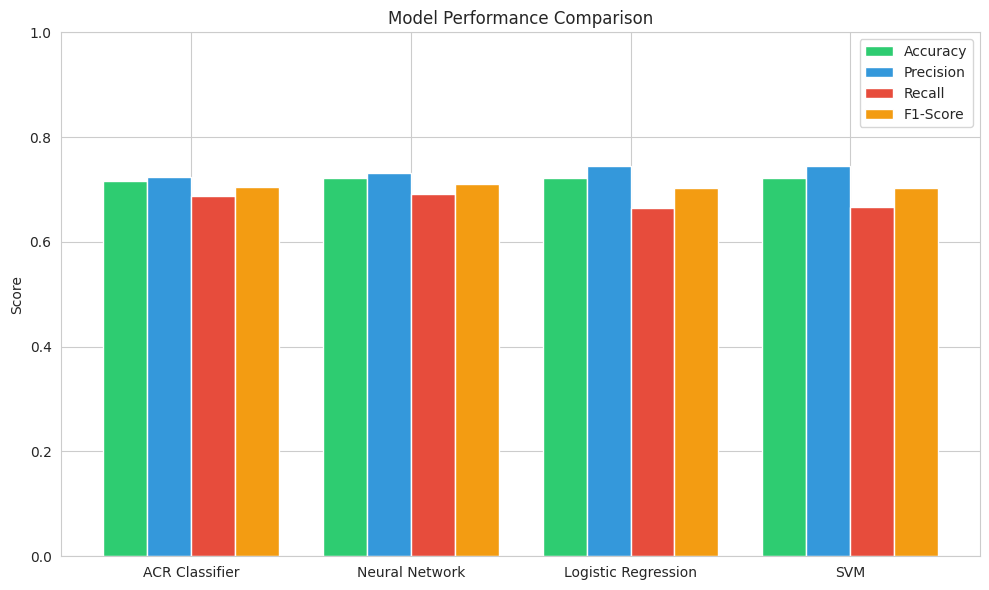

In [8]:
fig, ax = plt.subplots(figsize=(10, 6))
x = np.arange(len(metrics_df['Model']))
width = 0.2

ax.bar(x - 1.5*width, metrics_df['Accuracy'], width, label='Accuracy', color='#2ecc71')
ax.bar(x - 0.5*width, metrics_df['Precision'], width, label='Precision', color='#3498db')
ax.bar(x + 0.5*width, metrics_df['Recall'], width, label='Recall', color='#e74c3c')
ax.bar(x + 1.5*width, metrics_df['F1-Score'], width, label='F1-Score', color='#f39c12')

ax.set_ylabel('Score')
ax.set_title('Model Performance Comparison')
ax.set_xticks(x)
ax.set_xticklabels(metrics_df['Model'])
ax.legend()
ax.set_ylim([0, 1.0])

plt.tight_layout()
plt.show()

# 5. Summary and Conclusions